# LSTM-GCN with Rolling Pearson Correlation Graphs

This notebook implements an LSTM-GCN model that uses **rolling Pearson correlation graphs** instead of a single static precomputed graph.

**Key differences from the original LSTM-GCN:**
- Each sample gets its own adjacency matrix computed from rolling returns correlation
- Correlation lookback window is a hyperparameter (20, 40, 60 time steps)
- Correlation threshold (tau) is also configurable

**Output:** Same performance metrics as run_all_strategies.ipynb

## 1. Setup

In [1]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [2]:
import os
import sys

# Clone repo (Colab) or use local path
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/repo'...
remote: Enumerating objects: 453, done.
remote: Counting objects: 100% (453/453), done.
remote: Compressing objects: 100% (249/249), done.
remote: Total 453 (delta 237), reused 413 (delta 197), pack-reused 0 (from 0)
Receiving objects: 100% (453/453), 17.69 MiB | 15.62 MiB/s, done.
Resolving deltas: 100% (237/237), done.
Working directory: /content/repo/4YP-main


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
)

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/features.csv')

Mounted at /content/drive


## 2. Configuration

In [5]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = 6  # years

VOL_TARGET = 0.15  # 15% volatility target for normalization

# Rolling Pearson Configuration
CORRELATION_LOOKBACK = 20  # Options: 20, 40, 60
CORRELATION_THRESHOLD = 0.4  # Options: 0.3, 0.4, 0.5, 0.6

# Returns Type for Correlation Computation
# - False: Use straddle daily returns (simple returns from straddle prices)
# - True: Use equity log returns (matches lstm_gcn_static pearson methodology)
USE_EQUITY_RETURNS = True

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nRolling Pearson Configuration:")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK} time steps")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"  Returns type: {'EQUITY log returns' if USE_EQUITY_RETURNS else 'STRADDLE simple returns'}")

Train: 2011-2017
Test:  2017-2023

Rolling Pearson Configuration:
  Correlation lookback: 20 time steps
  Correlation threshold: 0.4
  Returns type: EQUITY log returns


## 3. Helper Functions

In [6]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    
    # Format percentages
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    
    # Format ratios
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Rolling 252-day Sharpe
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Yearly Sharpe Comparison
    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading and Preparation

In [7]:
# Load feature data
#features_path = "data/straddle_features/features.csv"
features_path = "/content/drive/MyDrive/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])
# Note: Do NOT set date as index - ModelFeatures expects it as a column

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88

Columns: ['Date', 'straddle_price', 'exdate', 'moneyness', 'daily_returns', 'daily_vol', 'target_returns', 'norm_daily_return', 'norm_monthly_return', 'norm_quarterly_return', 'norm_biannual_return', 'norm_annual_return', 'macd_2_8', 'macd_4_16', 'macd_8_32', 'day_of_week', 'day_of_month', 'month_of_year', 'year', 'log_moneyness', 'time_to_expiry', 'ticker', 'date']


In [8]:
# Import the rolling graph features class
from gml.graph_model_inputs import RollingGraphModelFeatures

# Create the feature generator with rolling Pearson configuration
rolling_features = RollingGraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    correlation_lookback=CORRELATION_LOOKBACK,
    correlation_threshold=CORRELATION_THRESHOLD,
    returns_column="daily_returns",
    use_equity_returns=USE_EQUITY_RETURNS,  # Toggle between straddle and equity returns
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
)

print("Feature generator created.")
print(f"Correlation returns: {'EQUITY log returns' if USE_EQUITY_RETURNS else 'STRADDLE simple returns'}")

Loading equity returns from cache: data/graph_structure/equity_returns/log_returns.csv
Equity returns shape: (3773, 88)
Equity date range: 2009-01-05 to 2023-12-29
no lags


train _batch
After final stacking and culling:
inputs.shape: (57, 88, 20, 10)
outputs.shape: (57, 88, 20, 1)
active_entries.shape: (57, 88, 20, 1)
identifier.shape: (57, 88, 20, 1)
date.shape: (57, 88, 20, 1)
Using EQUITY log returns for correlation (shape: (3773, 88))
adjacency.shape: (57, 88, 88)


valid _batch
After final stacking and culling:
inputs.shape: (14, 88, 20, 10)
outputs.shape: (14, 88, 20, 1)
active_entries.shape: (14, 88, 20, 1)
identifier.shape: (14, 88, 20, 1)
date.shape: (14, 88, 20, 1)
Using EQUITY log returns for correlation (shape: (3773, 88))
adjacency.shape: (14, 88, 88)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)
Using EQUITY l

In [ ]:
# Generate datasets with rolling adjacency matrices
# Adjacencies are computed automatically during initialization
datasets = rolling_features.make_rolling_graph_dataset(sliding_window=True)

train_data = datasets['train']
valid_data = datasets['valid']
test_data = datasets['test']

print("\nTraining data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")
print(f"  adjacency: {train_data['adjacency'].shape}")

print("\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"  outputs: {valid_data['outputs'].shape}")
print(f"  adjacency: {valid_data['adjacency'].shape}")

print("\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")
print(f"  outputs: {test_data['outputs'].shape}")
print(f"  adjacency: {test_data['adjacency'].shape}")


Training data:
  inputs: (57, 88, 20, 10)
  outputs: (57, 88, 20, 1)
  adjacency: (57, 88, 88)

Validation data:
  inputs: (14, 88, 20, 10)
  outputs: (14, 88, 20, 1)
  adjacency: (14, 88, 88)

Test data:
  inputs: (1400, 88, 20, 10)
  outputs: (1400, 88, 20, 1)
  adjacency: (1400, 88, 88)


## 5. Model Definition

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from gml.graph_model_2 import DynamicGraphConvolution, GraphSharpeLoss

def build_rolling_lstm_gcn_model(
    num_tickers,
    time_steps,
    input_size,
    hidden_layer_size=10,
    gcn_units=16,
    dropout_rate=0.4,
    learning_rate=0.001,
    max_gradient_norm=0.01,
    num_gcn_layers=2,
):
    """
    Build LSTM-GCN model with dynamic (per-sample) adjacency matrices.
    
    Args:
        num_tickers: Number of stocks/nodes (88)
        time_steps: Number of time steps per sample (20)
        input_size: Number of input features (10)
        hidden_layer_size: LSTM hidden units
        gcn_units: GCN output units
        dropout_rate: LSTM dropout
        learning_rate: Adam learning rate
        max_gradient_norm: Gradient clipping norm
        num_gcn_layers: Number of GCN layers (1 or 2)
    
    Returns:
        Compiled Keras model with two inputs: [features, adjacency]
    """
    # Input layers
    feature_input = keras.Input(
        shape=(num_tickers, time_steps, input_size),
        name="features"
    )
    adjacency_input = keras.Input(
        shape=(num_tickers, num_tickers),
        name="adjacency"
    )
    
    # Shared LSTM for all tickers
    shared_lstm = layers.LSTM(
        hidden_layer_size,
        return_sequences=True,
        dropout=dropout_rate,
        activation="tanh",
        recurrent_activation="sigmoid",
        name="shared_lstm"
    )
    
    # Process each ticker through shared LSTM
    lstm_outputs = []
    for i in range(num_tickers):
        ticker_slice = layers.Lambda(lambda x, idx=i: x[:, idx, :, :])(feature_input)
        ticker_output = shared_lstm(ticker_slice)
        lstm_outputs.append(ticker_output)
    
    # Stack LSTM outputs: (batch, time_steps, num_tickers, hidden)
    stacked_lstm = layers.Lambda(lambda tensors: tf.stack(tensors, axis=2))(lstm_outputs)
    print(f"Stacked LSTM shape: {stacked_lstm.shape}")
    
    # Apply Dynamic GCN layers
    gcn_output = DynamicGraphConvolution(units=gcn_units)([stacked_lstm, adjacency_input])
    gcn_output = layers.ReLU()(gcn_output)
    
    if num_gcn_layers == 2:
        gcn_output = DynamicGraphConvolution(units=gcn_units)([gcn_output, adjacency_input])
        gcn_output = layers.ReLU()(gcn_output)
    
    print(f"GCN output shape: {gcn_output.shape}")
    
    # Residual connection
    residual = layers.TimeDistributed(
        layers.TimeDistributed(
            keras.layers.Dense(gcn_units, activation="linear")
        )
    )(stacked_lstm)
    
    x = layers.Add()([gcn_output, residual])
    
    # Output layer
    output = layers.TimeDistributed(
        layers.TimeDistributed(
            keras.layers.Dense(
                1,
                activation=tf.nn.tanh,
                kernel_constraint=keras.constraints.max_norm(3),
            )
        )
    )(x)
    
    # Permute to match label shape: (batch, num_tickers, time_steps, 1)
    output = layers.Permute((2, 1, 3))(output)
    
    # Create model
    model = keras.Model(
        inputs=[feature_input, adjacency_input],
        outputs=output
    )
    
    # Compile
    adam = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=max_gradient_norm)
    sharpe_loss = GraphSharpeLoss(output_size=1).call
    
    model.compile(
        loss=sharpe_loss,
        optimizer=adam,
    )
    
    return model

LOADING graph_model_2.py - VERSION WITH run_trial DEBUG PRINTS


In [11]:
# Build the model
num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"Building model with:")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")

model = build_rolling_lstm_gcn_model(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    hidden_layer_size=10,
    gcn_units=16,
    dropout_rate=0.4,
    learning_rate=0.001,
    max_gradient_norm=0.01,
    num_gcn_layers=2,
)

#model.summary()

Building model with:
  num_tickers: 88
  time_steps: 20
  input_size: 10
Stacked LSTM shape: (None, 20, 88, 10)
GCN output shape: (None, 20, 88, 16)


## 6. Training

In [ ]:
# Prepare training data
X_train = [train_data['inputs'], train_data['adjacency']]
y_train = train_data['outputs']

X_valid = [valid_data['inputs'], valid_data['adjacency']]
y_valid = valid_data['outputs']

print(f"Training samples: {train_data['inputs'].shape[0]}")
print(f"Validation samples: {valid_data['inputs'].shape[0]}")

Training samples: 57
Validation samples: 14


In [13]:
# Training callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("="*60)
print("Training LSTM-GCN with Rolling Pearson Graphs")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK}")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print("="*60)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=NUM_EPOCHS,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GCN with Rolling Pearson Graphs
  Correlation lookback: 20
  Correlation threshold: 0.4
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 232s 52s/step - loss: 0.2236 - val_loss: -0.0308
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - loss: 0.2158 - val_loss: -0.1920
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step - loss: 0.0357 - val_loss: -0.3268
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step - loss: -7.9929e-04 - val_loss: -0.4284
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - loss: -0.1676 - val_loss: -0.5010
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - loss: -0.2198 - val_loss: -0.5606
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - loss: -0.3231 - val_loss: -0.6063
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step - loss: -0.3871 - val_loss: -0.6424
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - loss: -0.4309 - val_loss: -0.6710
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step - loss: -0.4487 - val_loss: -0.6972
Epoch 11/300
2/2 ━━━━━━━━━

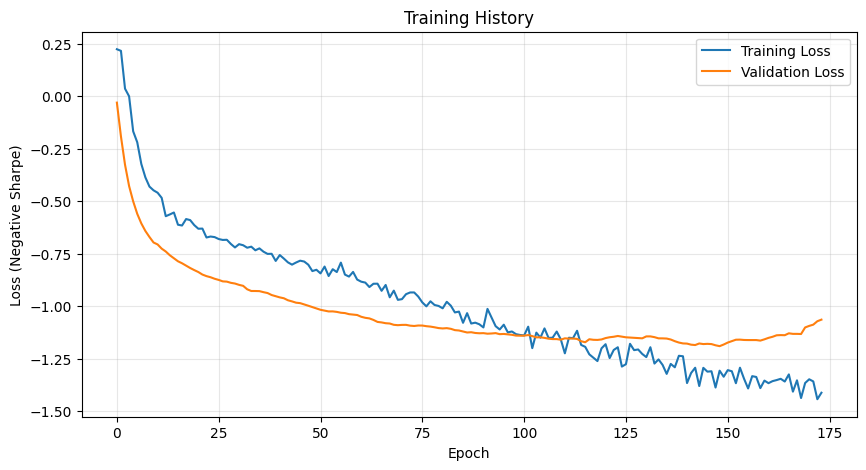

In [14]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Evaluation

In [15]:
# Generate predictions on test set
X_test = [test_data['inputs'], test_data['adjacency']]
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step 
Predictions shape: (1400, 88, 20, 1)
Test outputs shape: (1400, 88, 20, 1)


In [16]:
# Calculate captured returns (using last time step for sliding window)
# For sliding windows, extract the final time step to avoid double-counting
positions = predictions[:, :, -1, 0].reshape(-1)
returns = test_data['outputs'][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

# Get dates and identifiers
dates = test_data['date'][:, :, -1, 0].reshape(-1)
identifiers = test_data['identifier'][:, :, -1, 0].reshape(-1)

# Create results dataframe
results_df = pd.DataFrame({
    'time': dates,
    'identifier': identifiers,
    'position': positions,
    'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']  # Remove padding
results_df = results_df[results_df['time'].dt.year >= 2017]

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,0.119632,-0.009874,-0.001181
1,2017-01-03,ABT,-0.048165,-0.002442,0.000118
2,2017-01-03,ACN,-0.088659,-0.008236,0.000730
3,2017-01-03,ADBE,0.079963,-0.010764,-0.000861
4,2017-01-03,AIG,0.170885,-0.003832,-0.000655


In [17]:
# Calculate daily returns
daily_returns = calc_daily_returns(results_df)

# Raw metrics
print("\n" + "="*60)
print("LSTM-GCN Rolling Pearson Results (Raw)")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK}")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print("="*60)

metrics_raw = calc_metrics(daily_returns, "LSTM-GCN Rolling")
display_metrics(metrics_raw)

# Vol-normalized metrics
print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, "LSTM-GCN Rolling", VOL_TARGET)
display_metrics(metrics_norm)

# Yearly Sharpes
print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe in yearly_sharpes.items():
    print(f"  {year}: {sharpe:.4f}")


LSTM-GCN Rolling Pearson Results (Raw)
  Correlation lookback: 20
  Correlation threshold: 0.4


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Rolling,1.70%,1.44%,1.173,1.612,1.76%,0.964,57.29%,0.968



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Rolling (Vol-Norm),17.89%,15.00%,1.173,1.612,18.11%,0.988,57.29%,0.968



Yearly Sharpe Ratios:
  2017: 2.7358
  2018: 0.5377
  2019: 1.9217
  2020: 0.2461
  2021: 1.0352
  2022: 1.6742


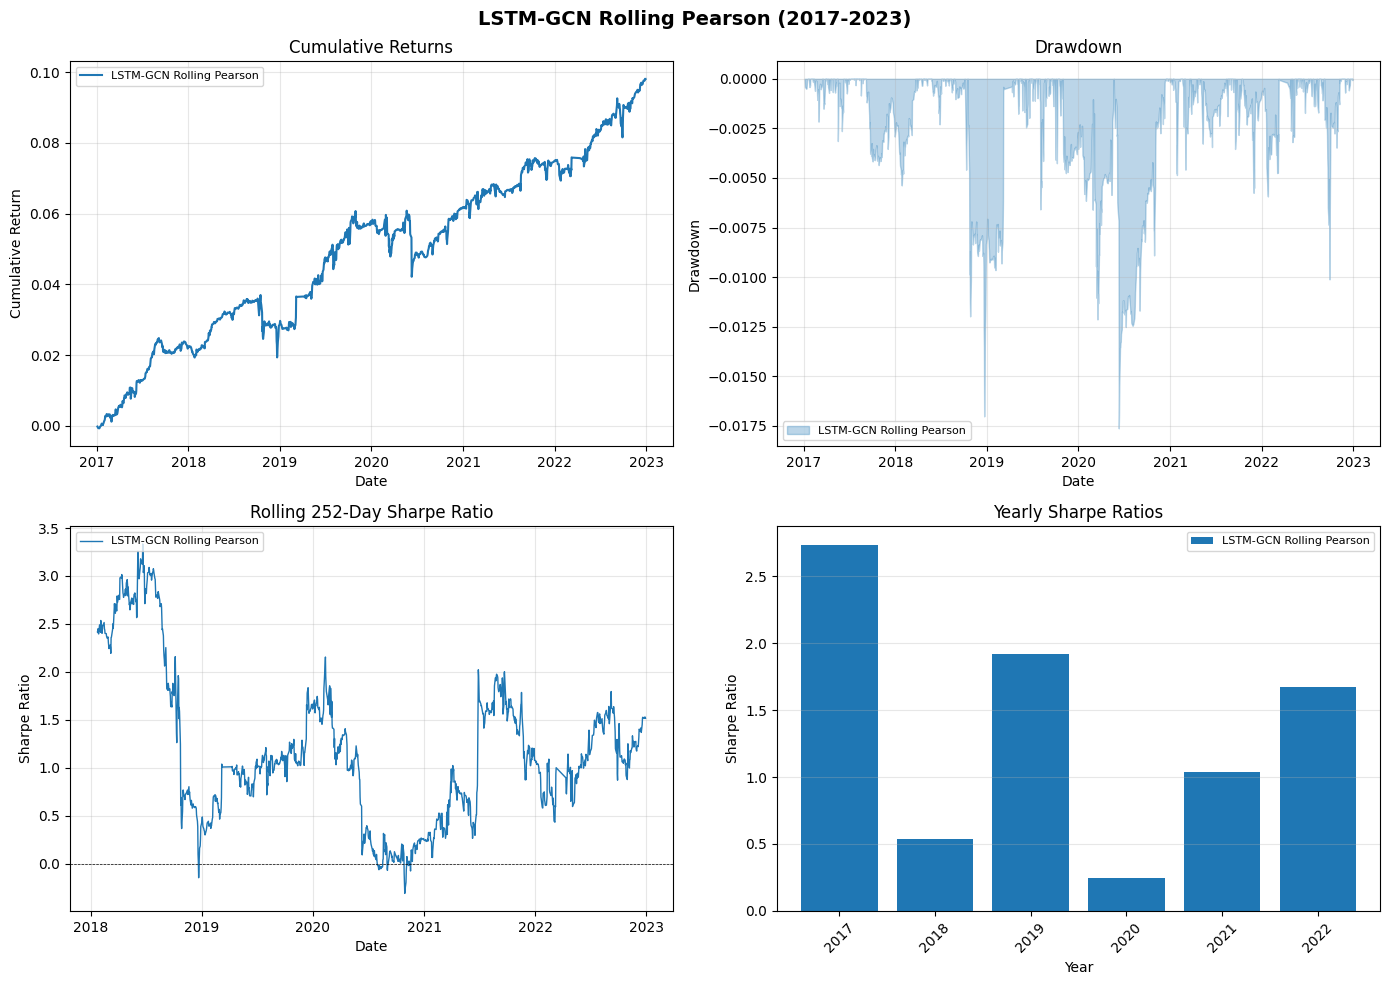

In [18]:
# Plot results
all_daily_returns = {'LSTM-GCN Rolling Pearson': daily_returns}
plot_results(all_daily_returns, f"LSTM-GCN Rolling Pearson ({TEST_START}-{TEST_END})")

## 8. Graph Visualization and Analysis

In [ ]:
from settings.default import ALL_TICKERS

def plot_adjacency_heatmap(adj, title, tickers=None):
    """Plot single adjacency matrix as heatmap."""
    plt.figure(figsize=(12, 10))
    if tickers is not None:
        sns.heatmap(adj, xticklabels=tickers, yticklabels=tickers, cmap='YlOrRd')
        plt.xticks(rotation=90, fontsize=6)
        plt.yticks(fontsize=6)
    else:
        sns.heatmap(adj, cmap='YlOrRd')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_adjacent_graphs(adjacencies, dates, start_idx=0):
    """Plot 4 consecutive adjacency matrices side-by-side."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    for i, ax in enumerate(axes.flat):
        idx = start_idx + i
        if idx < len(adjacencies):
            sns.heatmap(adjacencies[idx], ax=ax, cmap='YlOrRd', cbar=True)
            ax.set_title(f"Window {idx} ({dates[idx]})")
        else:
            ax.set_visible(False)
    plt.suptitle(f"Rolling Adjacency Matrices (Windows {start_idx} to {start_idx+3})")
    plt.tight_layout()
    plt.show()


def plot_graph_diff(adj1, adj2, title):
    """Visualize edge changes between two graphs."""
    diff = adj2 - adj1
    plt.figure(figsize=(12, 10))
    sns.heatmap(diff, cmap='RdBu', center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_edge_statistics(adjacencies):
    """Track number of edges over time."""
    num_edges = [(adj > 0).sum() / 2 for adj in adjacencies]
    
    plt.figure(figsize=(14, 4))
    plt.plot(num_edges, linewidth=0.8)
    plt.xlabel('Window Index')
    plt.ylabel('Number of Edges')
    plt.title('Graph Connectivity Over Time')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Edge statistics:")
    print(f"  Mean: {np.mean(num_edges):.1f}")
    print(f"  Std: {np.std(num_edges):.1f}")
    print(f"  Min: {np.min(num_edges):.0f}")
    print(f"  Max: {np.max(num_edges):.0f}")

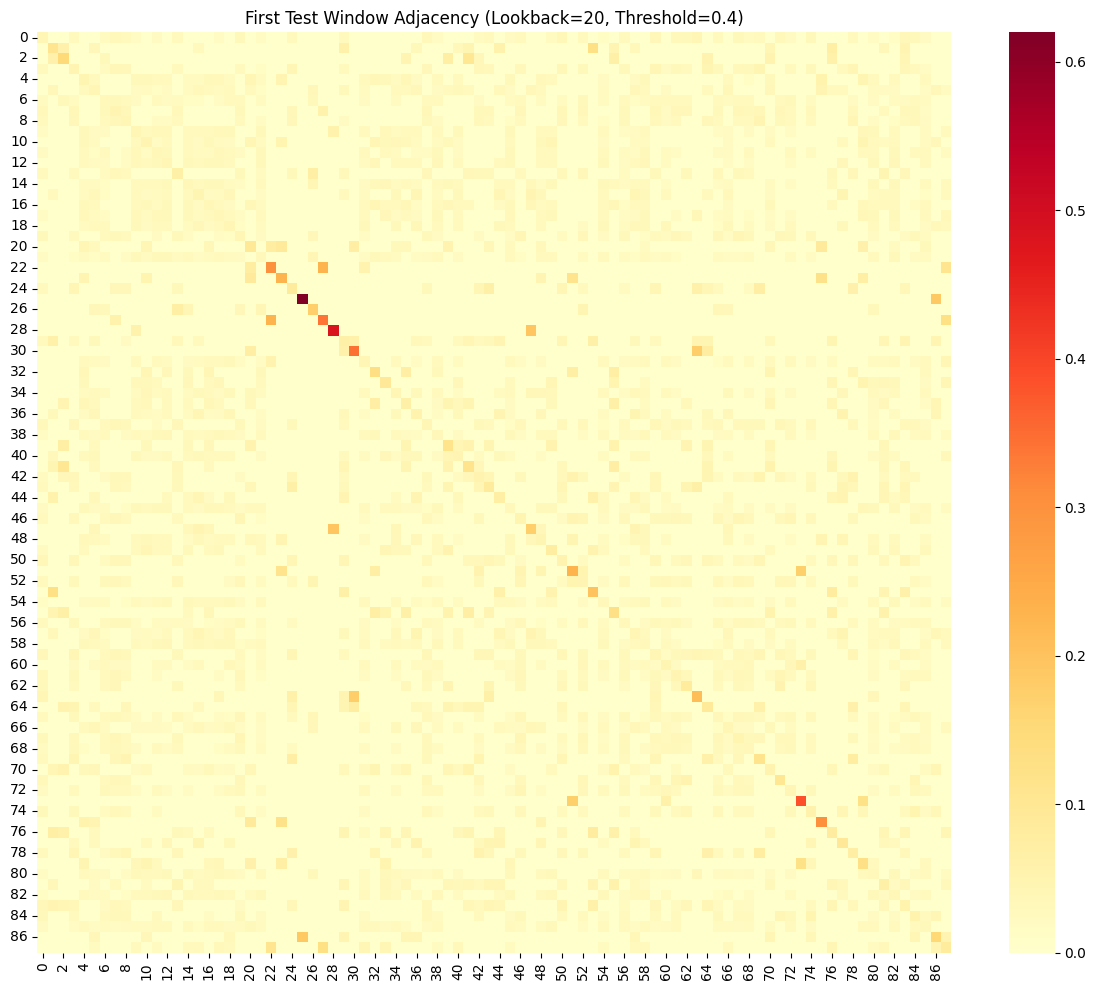

In [20]:
# Visualize first adjacency matrix
plot_adjacency_heatmap(
    test_data['adjacency'][0],
    f"First Test Window Adjacency (Lookback={CORRELATION_LOOKBACK}, Threshold={CORRELATION_THRESHOLD})"
)

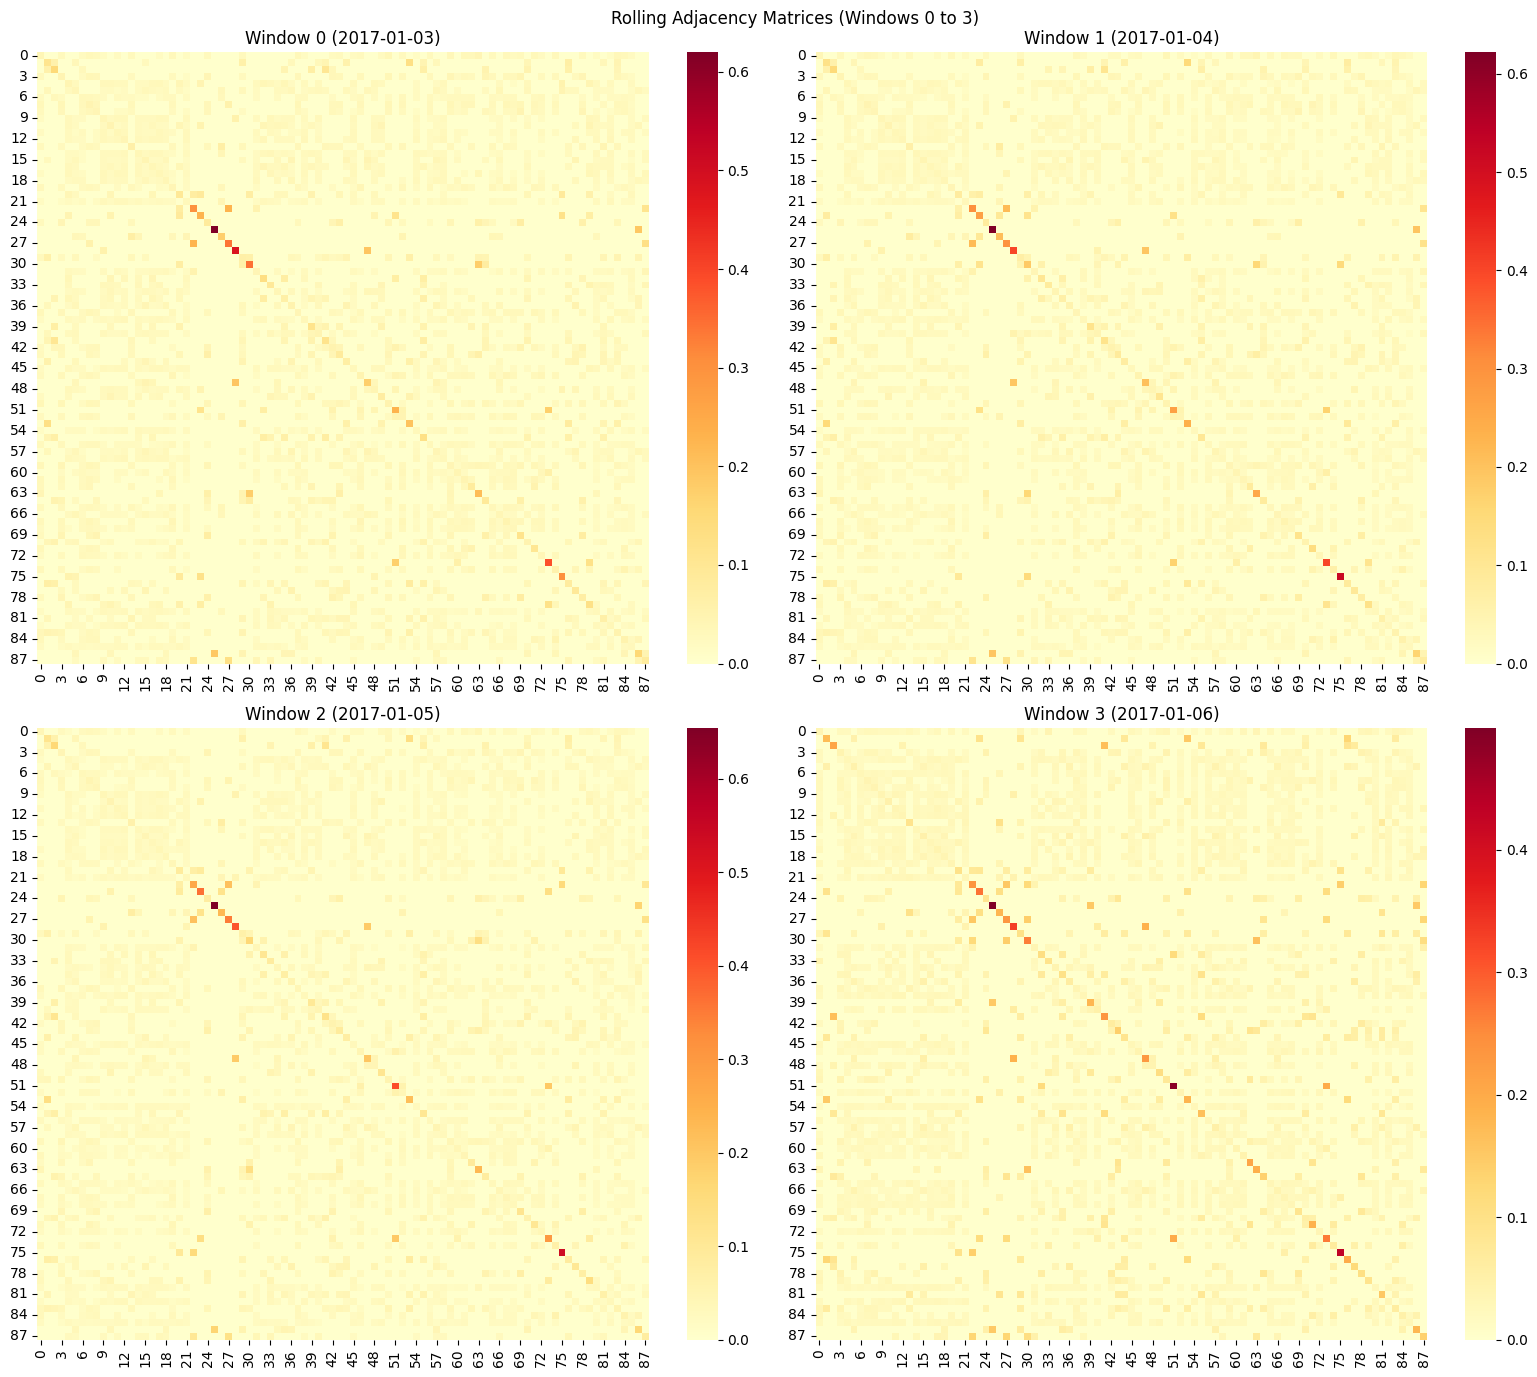

In [21]:
# Get window dates for visualization
test_dates = test_data['date'][:, 0, -1]  # Last date of each window
if test_dates.ndim > 1:
    test_dates = test_dates.squeeze()

# Plot 4 adjacent graphs
plot_adjacent_graphs(test_data['adjacency'], test_dates, start_idx=0)

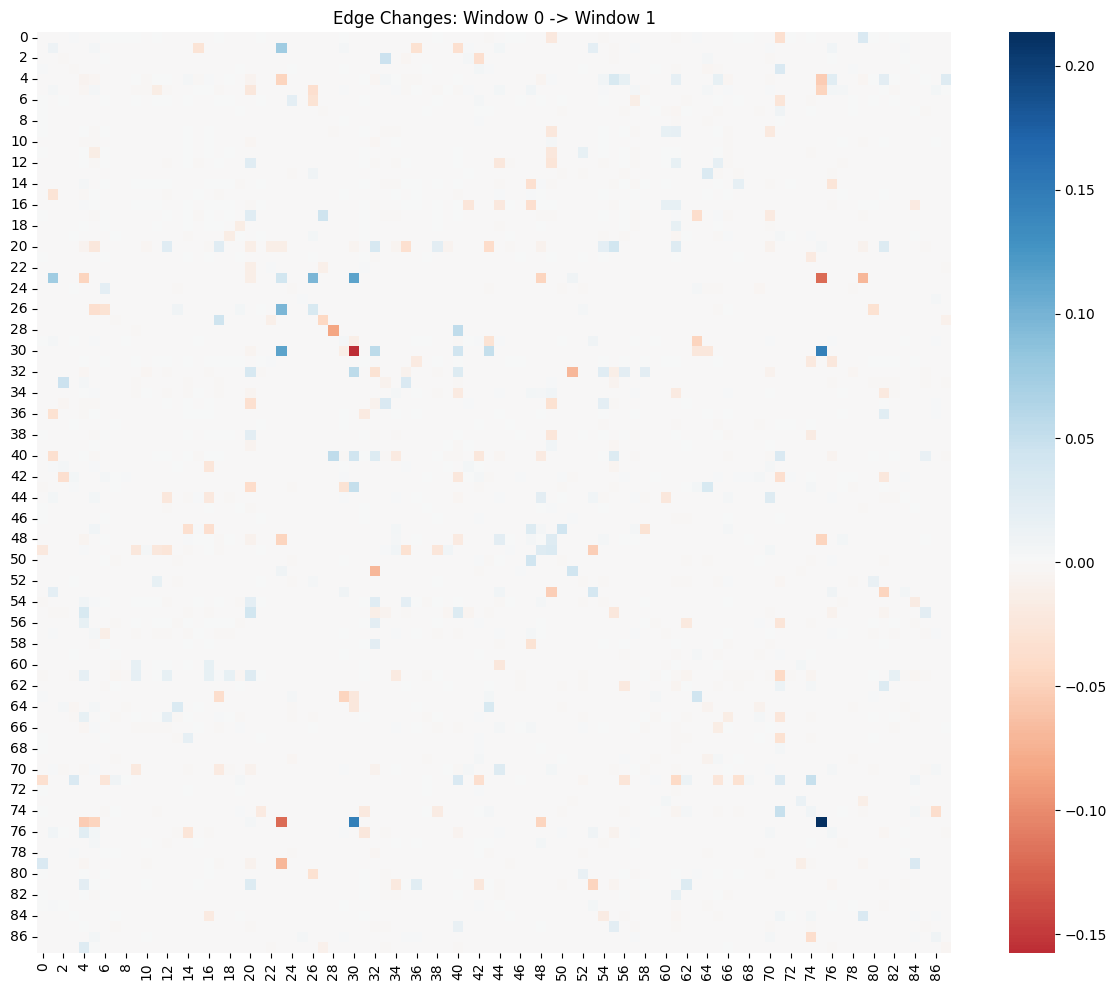

In [22]:
# Plot difference between first two graphs
plot_graph_diff(
    test_data['adjacency'][0],
    test_data['adjacency'][1],
    "Edge Changes: Window 0 -> Window 1"
)

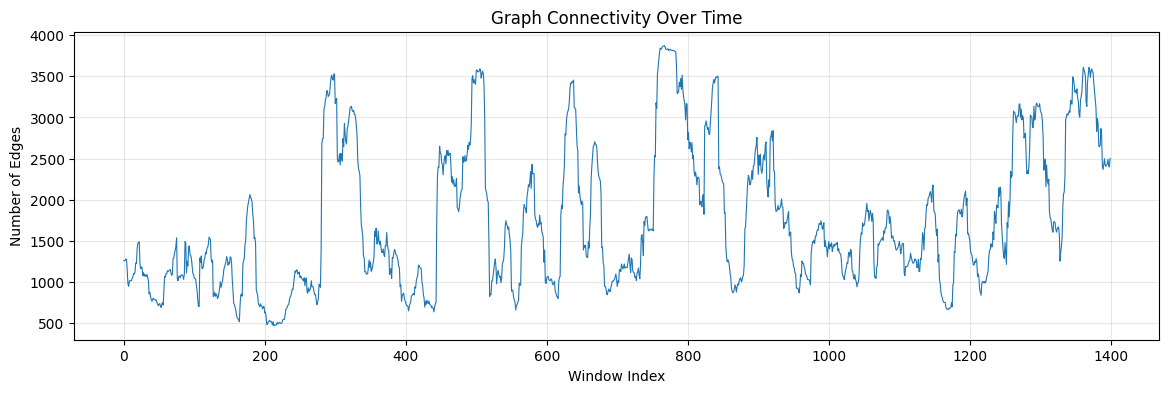

Edge statistics:
  Mean: 1739.3
  Std: 858.2
  Min: 466
  Max: 3872


In [23]:
# Plot edge statistics over time
plot_edge_statistics(test_data['adjacency'])

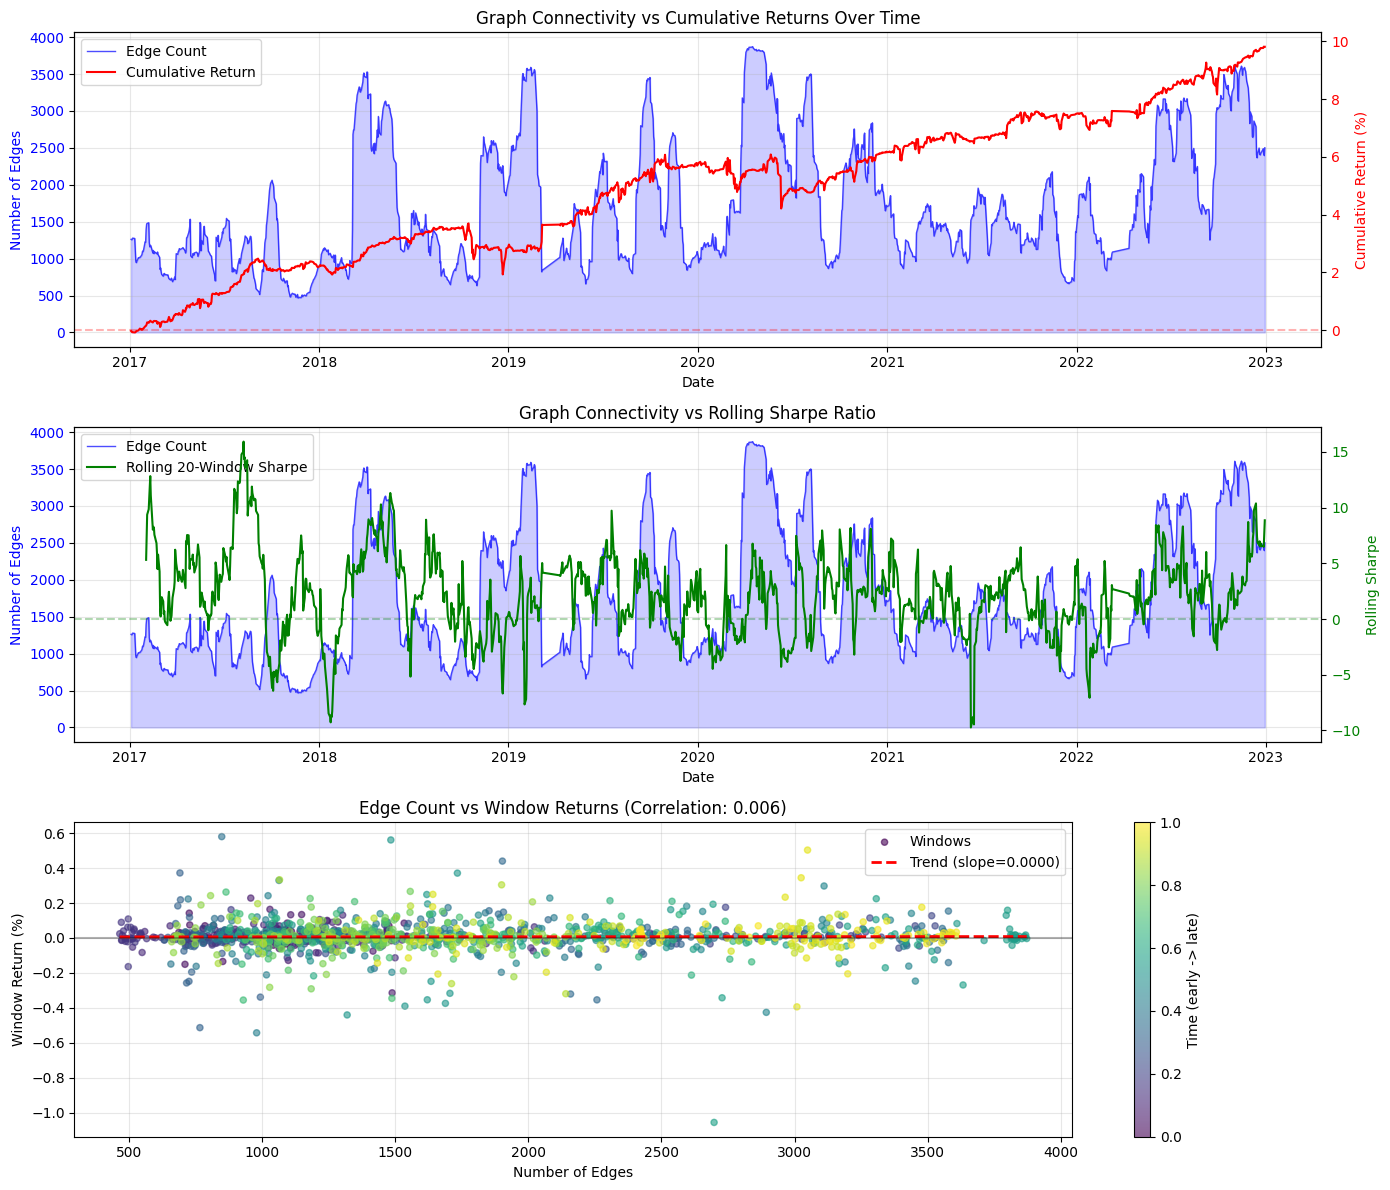


Connectivity-Performance Statistics:
  Correlation (edges vs returns): 0.0058
  Mean edges: 1739.3
  Mean window return: 0.0067%

  Low connectivity (<=1066 edges) mean return: 0.0084%
  High connectivity (>=2336 edges) mean return: 0.0074%


In [ ]:
# Connectivity vs Performance Analysis
from gml.connectivity_analysis import plot_connectivity_vs_performance

connectivity_stats = plot_connectivity_vs_performance(
    test_data['adjacency'], 
    results_df, 
    test_dates
)

Zooming into windows 100 to 103
Date range: 2017-06-05 to 2017-06-08


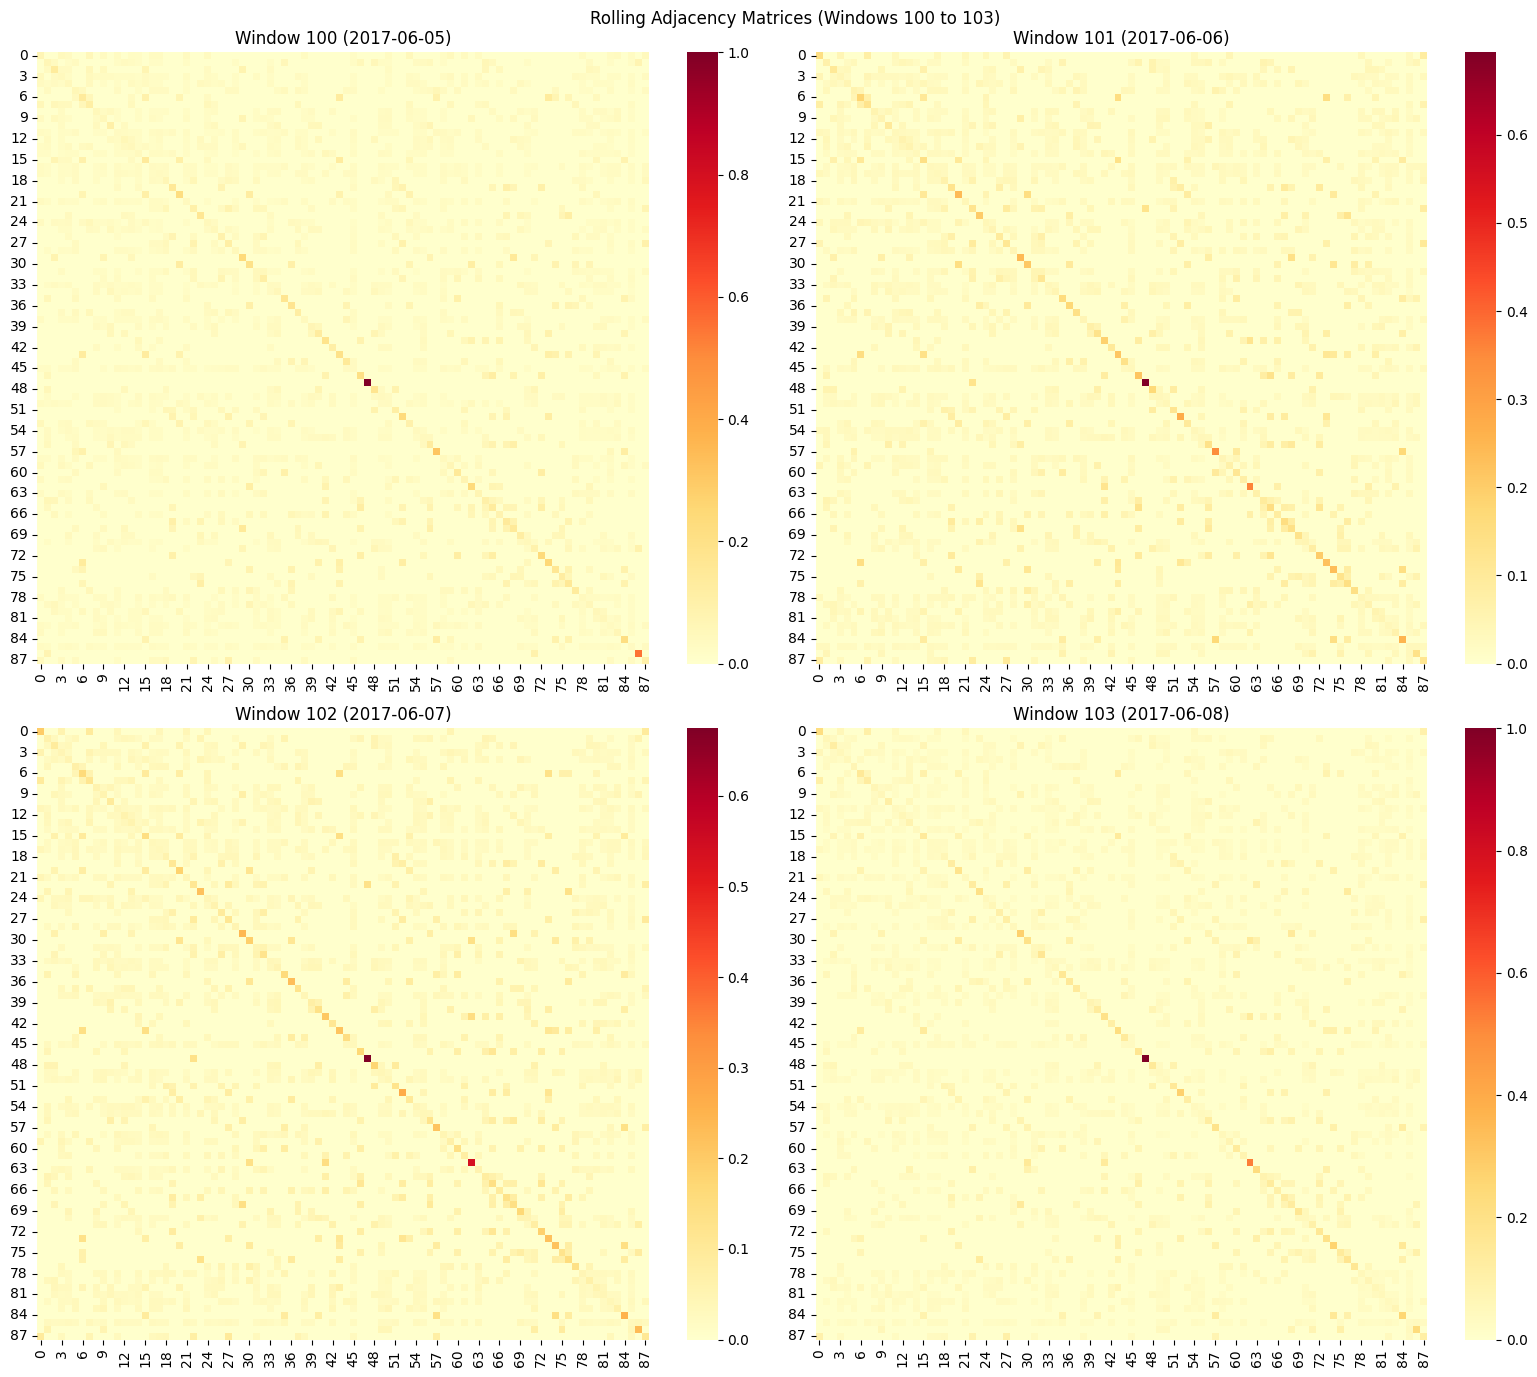

In [25]:
# Interactive zoom: specify window range
# Example: Zoom into a specific period
ZOOM_START = 100  # Change this to explore different periods

print(f"Zooming into windows {ZOOM_START} to {ZOOM_START + 3}")
print(f"Date range: {test_dates[ZOOM_START]} to {test_dates[min(ZOOM_START + 3, len(test_dates) - 1)]}")

plot_adjacent_graphs(test_data['adjacency'], test_dates, start_idx=ZOOM_START)

### Interactive Graph + Rolling Sharpe

Drag the slider to see the correlation graph at different dates, with rolling Sharpe below.

In [ ]:
# Rolling GCN already has per-sample adjacency matrices
all_graphs = test_data['adjacency']  # (num_windows, 88, 88)
print(f"Graphs shape: {all_graphs.shape}")

Graphs shape: (1400, 88, 88)


In [27]:
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from settings.default import ALL_TICKERS, BBG_SECTORS

# Sector colors
SECTOR_COLORS = {
    "Information Technology": "#1f77b4",
    "Healthcare": "#2ca02c",
    "Financials": "#ff7f0e",
    "Consumer Discretionary": "#d62728",
    "Consumer Staples": "#9467bd",
    "Industrials": "#8c564b",
    "Communication Services": "#e377c2",
    "Energy": "#7f7f7f",
    "Utilities": "#bcbd22",
    "Real Estate": "#17becf",
}

# Build a reference graph for fixed layout
tickers = sorted(ALL_TICKERS)
G_ref = nx.Graph()
for t in tickers:
    G_ref.add_node(t, sector=BBG_SECTORS.get(t, "Unknown"))

# Fixed node positions (computed once so nodes don't jump)
fixed_pos = nx.spring_layout(G_ref, k=2.5, iterations=100, seed=42)
node_colors = [SECTOR_COLORS.get(BBG_SECTORS.get(t, "Unknown"), "#cccccc") for t in tickers]

# Compute rolling Sharpe for the bottom panel
rolling_sharpe = daily_returns.rolling(252).mean() / daily_returns.rolling(252).std() * np.sqrt(252)

# Get test dates (one per window)
test_dates_arr = pd.to_datetime(test_data['date'][:, 0, -1, 0])

print(f"Ready: {len(all_graphs)} graphs, {len(test_dates_arr)} dates")

Ready: 1400 graphs, 1400 dates


In [28]:
# Interactive graph visualization with rolling Sharpe
EDGE_THRESHOLD = 0.05  # Minimum attention/correlation weight to show as edge

output_widget = widgets.Output()

def update_graph(window_idx):
    with output_widget:
        clear_output(wait=True)
        
        fig, (ax_graph, ax_sharpe) = plt.subplots(
            2, 1, figsize=(14, 16),
            gridspec_kw={'height_ratios': [3, 1]}
        )
        
        # --- Top: Network graph ---
        adj = all_graphs[window_idx]
        date_str = str(test_dates_arr[window_idx].date())
        
        # Build graph for this window
        G = nx.Graph()
        for t in tickers:
            G.add_node(t)
        
        n = len(tickers)
        for i in range(n):
            for j in range(i + 1, n):
                w = (adj[i, j] + adj[j, i]) / 2  # symmetrize
                if abs(w) > EDGE_THRESHOLD:
                    G.add_edge(tickers[i], tickers[j], weight=w)
        
        # Draw edges
        edges = G.edges(data=True)
        if len(edges) > 0:
            weights = [d['weight'] for _, _, d in edges]
            max_w = max(abs(w) for w in weights) if weights else 1.0
            for (u, v, d) in edges:
                w = d['weight']
                width = 2.0 * abs(w) / max_w
                alpha = 0.3 + 0.7 * abs(w) / max_w
                x = [fixed_pos[u][0], fixed_pos[v][0]]
                y = [fixed_pos[u][1], fixed_pos[v][1]]
                ax_graph.plot(x, y, color='gray', linewidth=width, alpha=alpha, zorder=1)
        
        # Draw nodes
        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors,
                               node_size=600, alpha=0.9, ax=ax_graph)
        nx.draw_networkx_labels(G, fixed_pos, font_size=6, font_weight='bold', ax=ax_graph)
        
        num_edges = G.number_of_edges()
        ax_graph.set_title(f"Graph at {date_str}  |  {num_edges} edges (threshold={EDGE_THRESHOLD})",
                          fontsize=14, fontweight='bold')
        ax_graph.axis('off')
        
        # --- Bottom: Rolling Sharpe with date marker ---
        ax_sharpe.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color='blue')
        ax_sharpe.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax_sharpe.axvline(x=test_dates_arr[window_idx], color='red', linewidth=2, alpha=0.8)
        ax_sharpe.set_title('Rolling 252-Day Sharpe Ratio', fontsize=12)
        ax_sharpe.set_xlabel('Date')
        ax_sharpe.set_ylabel('Sharpe')
        ax_sharpe.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

slider = widgets.IntSlider(
    min=0, max=len(all_graphs) - 1, step=1, value=0,
    description='Window:',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

widgets.interactive(update_graph, window_idx=slider)
display(slider, output_widget)
update_graph(0)  # Show initial frame

IntSlider(value=0, continuous_update=False, description='Window:', layout=Layout(width='80%'), max=1399)

Output()

## 9. Save Results

In [29]:
# Create results directory
returns_type = "equity" if USE_EQUITY_RETURNS else "straddle"
results_dir = f"results/lstm_gcn_rolling_pearson_{returns_type}_lb{CORRELATION_LOOKBACK}_th{CORRELATION_THRESHOLD}/{TEST_START}-{TEST_END}"
os.makedirs(results_dir, exist_ok=True)

# Save captured returns
results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)

# Save metrics
metrics_df = pd.DataFrame([metrics_raw])
metrics_df.to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)

metrics_norm_df = pd.DataFrame([metrics_norm])
metrics_norm_df.to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)

# Save yearly Sharpes
yearly_df = pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe'])
yearly_df.to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gcn_rolling_pearson_equity_lb20_th0.4/2017-2023


## 10. Summary

In [30]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nModel: LSTM-GCN with Rolling Pearson Graphs")
print(f"\nRolling Pearson Configuration:")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK} time steps")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"  Returns type: {'EQUITY log returns' if USE_EQUITY_RETURNS else 'STRADDLE simple returns'}")
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nPerformance (Raw):")
print(f"  Sharpe Ratio: {metrics_raw['Sharpe']:.3f}")
print(f"  Annual Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Annual Volatility: {metrics_raw['Vol.']:.2%}")
print(f"  Sortino Ratio: {metrics_raw['Sortino']:.3f}")
print(f"  Max Drawdown: {metrics_raw['Max DD']:.2%}")

EXPERIMENT SUMMARY

Model: LSTM-GCN with Rolling Pearson Graphs

Rolling Pearson Configuration:
  Correlation lookback: 20 time steps
  Correlation threshold: 0.4
  Returns type: EQUITY log returns

Training Period: 2011 - 2017
Test Period:     2017 - 2023

Performance (Raw):
  Sharpe Ratio: 1.173
  Annual Return: 1.70%
  Annual Volatility: 1.44%
  Sortino Ratio: 1.612
  Max Drawdown: 1.76%


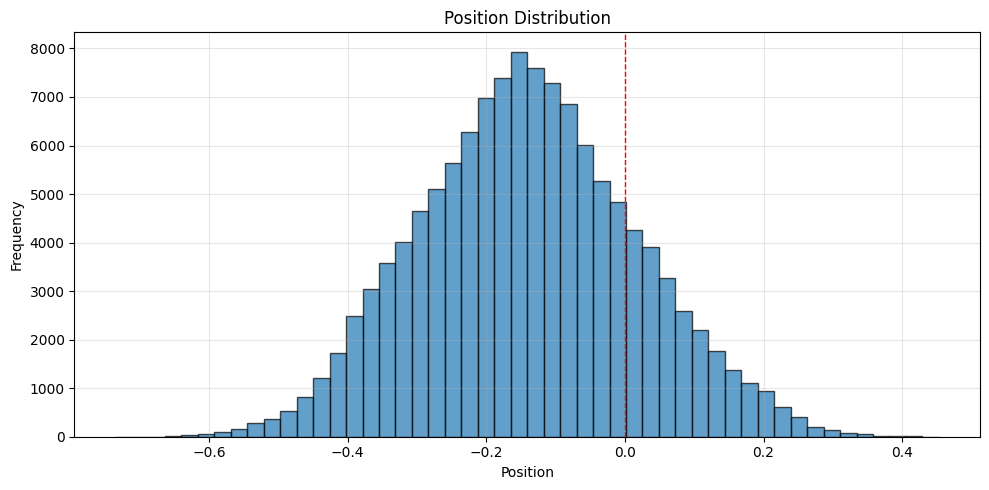

In [31]:
# Position distribution
plt.figure(figsize=(10, 5))
plt.hist(results_df['position'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.title('Position Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
from gml.experiment_utils import save_experiment_results

EXPERIMENT_NAME = "3_GCN_rolling_pearson"
SEED = 42

if 'google.colab' in str(get_ipython()):
    RESULTS_BASE = "/content/drive/MyDrive/FINAL_RESULTS"
else:
    RESULTS_BASE = "FINAL_RESULTS"

returns_type = "equity" if USE_EQUITY_RETURNS else "straddle"
CONFIG_NAME = f"lb{CORRELATION_LOOKBACK}_th{CORRELATION_THRESHOLD}_{returns_type}"

test_dates_arr = pd.to_datetime(test_data['date'][:, 0, -1, 0])

hyperparams = {
    "model_type": "GCN_rolling_pearson",
    "hidden_layer_size": 10,
    "gcn_units": 16,
    "num_gcn_layers": 2,
    "dropout_rate": 0.4,
    "learning_rate": 0.001,
    "max_gradient_norm": 0.01,
    "batch_size": 64,
    "correlation_lookback": CORRELATION_LOOKBACK,
    "correlation_threshold": CORRELATION_THRESHOLD,
    "use_equity_returns": USE_EQUITY_RETURNS,
    "total_time_steps": 20,
    "train_start": TRAIN_START,
    "test_start": TEST_START,
    "test_end": TEST_END,
}

save_experiment_results(
    experiment_name=EXPERIMENT_NAME,
    seed=SEED,
    config_name=CONFIG_NAME,
    predictions=predictions,
    results_df=results_df,
    daily_returns=daily_returns,
    metrics_raw=metrics_raw,
    metrics_norm=metrics_norm,
    yearly_sharpes=yearly_sharpes,
    training_history=history.history,
    hyperparams=hyperparams,
    test_dates=test_dates_arr.values,
    adjacency=test_data['adjacency'],  # all rolling adjacency matrices (1400, 88, 88)
    model=model,
    base_dir=RESULTS_BASE,
)

Results saved to: /content/drive/MyDrive/FINAL_RESULTS/3_GCN_rolling_pearson/lb20_th0.4_equity/seed_42
Saved 11 files:
  captured_returns_sw.csv (8.1 MB)
  metrics_raw.csv (241 B)
  metrics_vol_normalized.csv (250 B)
  yearly_sharpes.csv (156 B)
  daily_returns.csv (46.1 KB)
  training_history.json (8.5 KB)
  hyperparams.json (391 B)
  predictions.npy (9.4 MB)
  test_dates.npy (11.1 KB)
  adjacency.npy (82.7 MB)
  model_weights/weights.weights.h5 (237.7 KB)
